In [1]:
import r5py as r5
import h3
import geopandas as gpd
from shapely.geometry import Polygon
from pyrosm import OSM
import numpy as np
from pyrosm.data import sources
from pyrosm import get_data
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
from pathlib import Path
from r5py.util import Config

cache_dir = Path(Config().CACHE_DIR)  # persistent cache directory
print("CACHE_DIR:", cache_dir)

for f in cache_dir.glob("*.mapdb*"):
    print("Deleting", f)
    f.unlink()

In [3]:
osm_path = "cities/copenhagen/Copenhagen.osm.pbf"
gtfs_path = ""

In [4]:
osm = OSM(osm_path)
boundaries = osm.get_boundaries()

In [5]:
lookup_table = boundaries.dropna(subset=['name'])[['name', 'admin_level', 'boundary']]

lookup_table = lookup_table.drop_duplicates()

# Sort by admin_level (lowest number to highest) and display all
pd.set_option('display.max_rows', None) # Ensures Jupyter shows the whole list
display(lookup_table.sort_values('admin_level'))

,name,admin_level,boundary
0,Danmark,2,administrative
1,Sverige,2,administrative
2,Skåne län,4,administrative
4,Region Sjælland,4,administrative
5,Region Hovedstaden,4,administrative
27,Dragør Kommune,7,administrative
26,Hvidovre Kommune,7,administrative
25,Brøndby Kommune,7,administrative
24,Rudersdal Kommune,7,administrative
23,Furesø Kommune,7,administrative


In [ ]:
level_7_df = lookup_table[lookup_table['admin_level'] == '7']

admin_7_list = level_7_df['name'].unique().tolist()
admin_7_list

In [70]:
correct_municipalities = [ 'Hvidovre Kommune',
 'Dragør Kommune',
 'Tårnby Kommune',
 'Københavns Kommune']#[name for name in admin_7_list if name.endswith("Kommune")]

In [71]:
city_boundary = boundaries[boundaries["name"].isin(correct_municipalities)]

# Automatically calculate the best local UTM CRS for this specific geometry
local_crs = city_boundary.estimate_utm_crs()
city_proj = city_boundary.to_crs(local_crs)

<Axes: >

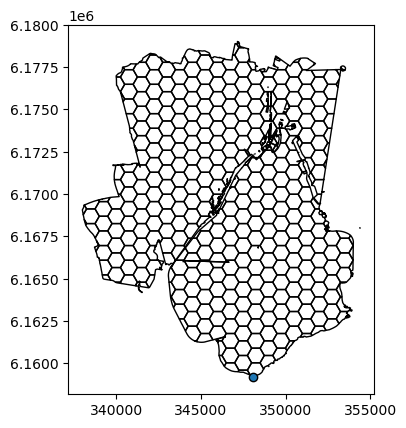

In [72]:
def create_hex_grid(gdf, radius_meters):
    xmin, ymin, xmax, ymax = gdf.total_bounds
    
    # Mathematical constants for a flat-topped hexagon
    w = 2 * radius_meters
    h = np.sqrt(3) * radius_meters
    
    # Calculate spacing
    x_coords = np.arange(xmin - w, xmax + w, 1.5 * radius_meters)
    y_coords = np.arange(ymin - h, ymax + h, h)
    
    polys = []
    for i, x in enumerate(x_coords):
        for j, y in enumerate(y_coords):
            # Offset every odd column to lock the hexagons together
            y_curr = y + (h / 2) if i % 2 == 1 else y
            
            # Generate the 6 vertices
            hex_points = [
                (x + radius_meters * np.cos(angle), y_curr + radius_meters * np.sin(angle))
                # 6 equidistant points around a circle
                for angle in np.linspace(0, 2 * np.pi, 7)[:-1] 
            ]
            polys.append(Polygon(hex_points))
            
    # Convert to GeoDataFrame
    grid = gpd.GeoDataFrame({'geometry': polys}, crs=gdf.crs)
    
    # Strictly clip the grid to the city boundary so it doesn't spill over
    return gpd.clip(grid, gdf)

# Generate a grid where each hexagon has a center-to-corner radius of n meters
grid = create_hex_grid(city_proj, radius_meters=500)

# Plot the result
grid.plot(edgecolor='black', facecolor='none')


In [6]:
buildings = osm.get_buildings()

In [43]:
# Road network
# You can specify network_type="driving", "walking", "cycling", or "all"
drive_net = osm.get_network(network_type="driving")

In [20]:
# Landuse: contains zones categorized as 'residential', 'commercial', 'forest', etc.
landuse = osm.get_landuse()

In [19]:
# POIs
pois = osm.get_pois() 

### **Spatial join**
(merge spatial data with hex nodes)

In [ ]:
# 1. Give each hexagon a unique ID so we can group data by it later
grid['hex_id'] = range(len(grid))

# 2. Ensure the CRS (Coordinate Reference System) matches exactly!
# A spatial join will fail or be wildly inaccurate if the grid is in meters 
# and the POIs are still in raw GPS coordinates (longitude/latitude).
pois_proj = pois.to_crs(grid.crs)

# (Optional) Filter the POIs. Let's say we only want to count restaurants and cafes
food_pois = pois_proj[pois_proj['amenity'].isin(['restaurant', 'cafe', 'fast_food'])]

# 3. Perform the Spatial Join
# This asks: "Which hexagon (custom_hex_grid) does each point (food_pois) fall inside?"
points_in_hex = gpd.sjoin(
    food_pois, 
    grid, 
    how="inner",        # Only keep points that successfully matched a hexagon
    predicate="within"  # The point must be geometrically inside the polygon
)

# 4. Count the points per hexagon
# We group by the unique hex_id we created in step 1
hex_counts = points_in_hex.groupby('hex_id').size().reset_index(name='poi_count')

# 5. Merge the counts back onto the original hex grid GeoDataFrame
# We use how="left" so hexagons with 0 points aren't deleted
hex_grid_with_data = grid.merge(hex_counts, on='hex_id', how='left')

# Replace NaN values with 0 (since no match means 0 POIs)
hex_grid_with_data['poi_count'] = hex_grid_with_data['poi_count'].fillna(0)

# 6. Plot the results as a Choropleth map!
fig, ax = plt.subplots(figsize=(12, 12))

# Plot the hexagons, coloring them by the 'poi_count' column
hex_grid_with_data.plot(
    column='poi_count', 
    cmap='YlOrRd',          # Yellow to Orange to Red color scale
    linewidth=0.1, 
    edgecolor='gray', 
    legend=True,
    legend_kwds={'label': "Number of Food POIs"},
    ax=ax
)

ax.set_title("Food Density in the Copenhagen Area", fontsize=16)
ax.set_axis_off()
plt.show()


: 

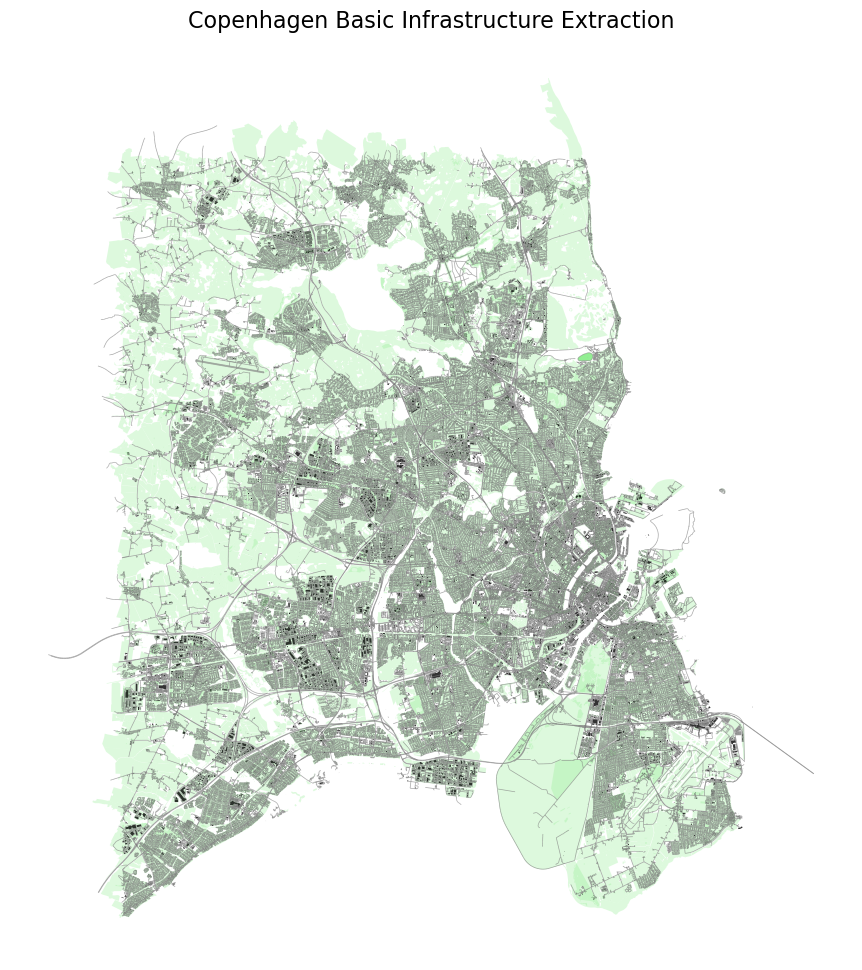

In [22]:
fig, ax = plt.subplots(figsize=(12, 12))

# Plot landuse (e.g., parks/water) as the base layer
if landuse is not None and not landuse.empty:
    landuse.plot(ax=ax, color='lightgreen', alpha=0.3, edgecolor='none')

# Plot the road network on top
if drive_net is not None and not drive_net.empty:
    drive_net.plot(ax=ax, color='gray', linewidth=0.5, alpha=0.7)

# Plot buildings in black
if buildings is not None and not buildings.empty:
    buildings.plot(ax=ax, color='black', alpha=0.8)

ax.set_title("Copenhagen Basic Infrastructure Extraction", fontsize=16)
ax.set_axis_off()
plt.show()

In [15]:
from pyrosm import get_data
fp = get_data("Copenhagen")
print(fp)

Downloaded Protobuf data 'Copenhagen.osm.pbf' (48.41 MB) to:
'C:\Users\hp\AppData\Local\Temp\pyrosm\Copenhagen.osm.pbf'
C:\Users\hp\AppData\Local\Temp\pyrosm\Copenhagen.osm.pbf


In [ ]:
'''network = r.TransportNetwork(osm_pbf=hel.osm_pbf, gtfs=hel.gtfs, elevation_model=hel.elevation_model, elevation_cost_function=r.ElevationCostFunction.TOBLER)
population = gpd.read_file(hel.population_grid)
population.head()'''

,id,population,geometry
0,0,389,"POLYGON ((24.90545 60.16086, 24.90545 60.16311..."
1,1,296,"POLYGON ((24.90546 60.15862, 24.90545 60.16086..."
2,2,636,"POLYGON ((24.90547 60.15638, 24.90546 60.15862..."
3,3,1476,"POLYGON ((24.90547 60.15413, 24.90547 60.15638..."
4,4,23,"POLYGON ((24.90994 60.16535, 24.90994 60.1676,..."
